In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('13-WineQT.csv') 

# Şarapların birkaç input datası var ve bu datalara göre bir de output değeri olan kalite puanı datası var. Bu datadan çıkarabildiğimiz kadar sonuç 
# çıkaracağız. Şimdiye kadar öğrendiklerimizi kullan!!!

In [4]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [5]:
data = data.set_index("Id")

# Id yi index yapmak istedim...

In [6]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5


In [7]:
# 1-) En çok hangi değişkenler bizim kalitemizi etkiliyorlar? ***
# 2-) Ortalama değerler nedir? sitrik asitte , şekerde , kloritte ? (+)
# 3-) 10 alan kaç şarap var ? 8 alan 5 alan gibi gibi? En çok hangi quality değerinde toplanmışlar? (+)
# 4- Alkol oranı dağılımı nedir? Alkor oranı yüksek olanlar mı düşük olanlar mı daha fazla gibi sorular... (+)
# 5- Outlier'lar var mı?  (?)
# vb. sonuçlar çıkarmaya çalışalım.

In [8]:
data.info() # null değer yok.

<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 116.1 KB


In [9]:
data.describe() # mean değerlerini burda da görebiliriz!

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [10]:
data["citric acid"].mean()

np.float64(0.2683639545056868)

In [11]:
data["chlorides"].mean()

np.float64(0.08693263342082239)

In [12]:
data["residual sugar"].mean()

np.float64(2.5321522309711284)

In [13]:
# 2. sorudaki değerlerin ortalama değerlerini bulduk. Diğer değerleri de bu şekilde basitçe bulabiliriz.

In [14]:
quality_10 = (data["quality"] == 10).sum()

In [15]:
quality_10

# quality 10 olan şarap yokmuş!

np.int64(0)

In [16]:
data["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [30]:
data.duplicated()
# Yani duplicated() sana hangi satırlar tekrar ediyor onu gösteriyor.

Id
0       False
1       False
2       False
3       False
4        True
        ...  
1592    False
1593    False
1594    False
1595    False
1597    False
Length: 1143, dtype: bool

In [32]:
data[data.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
91,8.6,0.490,0.28,1.90,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6
93,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.99660,3.39,0.64,9.6,5
102,8.1,0.545,0.18,1.90,0.080,13.0,35.0,0.99720,3.30,0.59,9.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1507,7.5,0.380,0.57,2.30,0.106,5.0,12.0,0.99605,3.36,0.55,11.4,6
1560,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1561,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5


In [17]:
# ortalamasına bakalım bir. 

data["quality"].mean()

np.float64(5.657042869641295)

In [18]:
(data["quality"] == 5).sum()  # 483 tane quality = 5 değerine sahip şarap varmış. Ortalamaya baktığımızda bu kadar fazla olduğunu tahmin edebildik.

np.int64(483)

In [19]:
(data["quality"] == 6).sum()

np.int64(462)

In [20]:
# 5 ve 6 aralığında toplanmışlar çoğunlukla. Bunu görselleştirelim ve öyle görelim

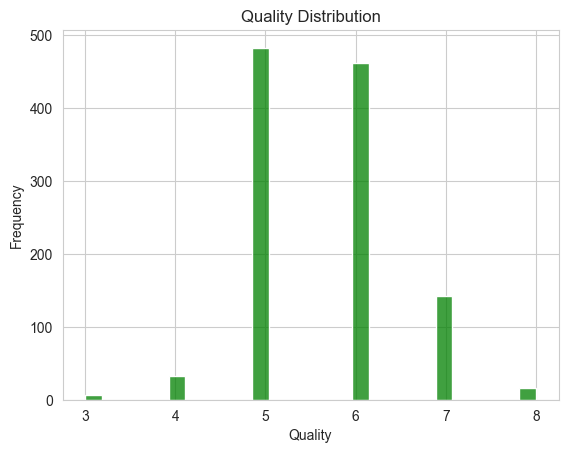

In [21]:
sns.set_style("whitegrid")
sns.histplot(x="quality", data=data, color = "green") # histogramla sayısal değerlerini daha açık ve net görelim.
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.title("Quality Distribution")

plt.show()

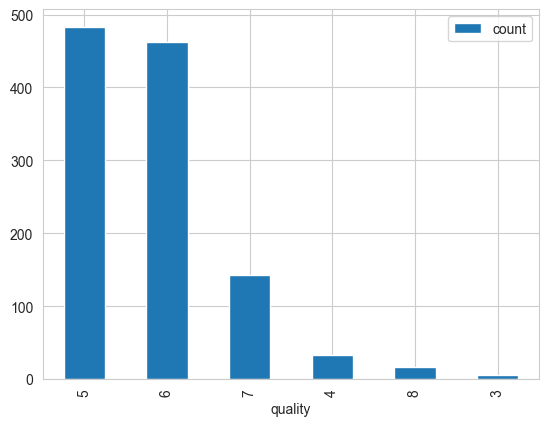

In [40]:
data["quality"].value_counts().plot(kind="bar")
plt.legend()
plt.show()

#data["quality"].value_counts() Bu kısım quality count değerlerini sayısal olarak gösterir. Bu koddan sonra plotla yazdığımız kısımla grafik haline
# getirebiliyoruz!!

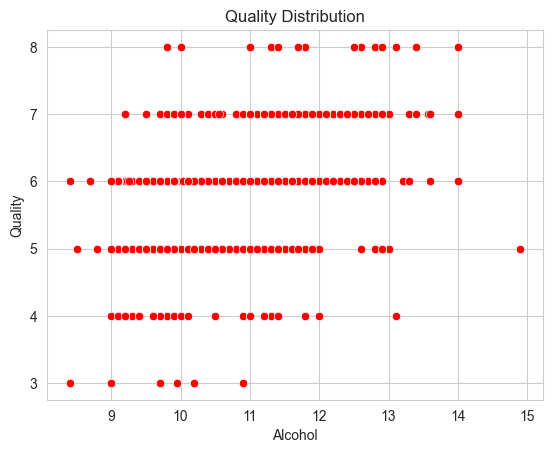

In [22]:
sns.set_style("whitegrid")
sns.scatterplot(x="alcohol",y="quality", data=data , color = "red") 
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Quality Distribution")

plt.show()

# Burada alkol oranının kaliteyi nasıl etkilediğini görmek istedim. Pozitif kolerasyon mevcut. Oran arttıkça genellikle kalite artmış

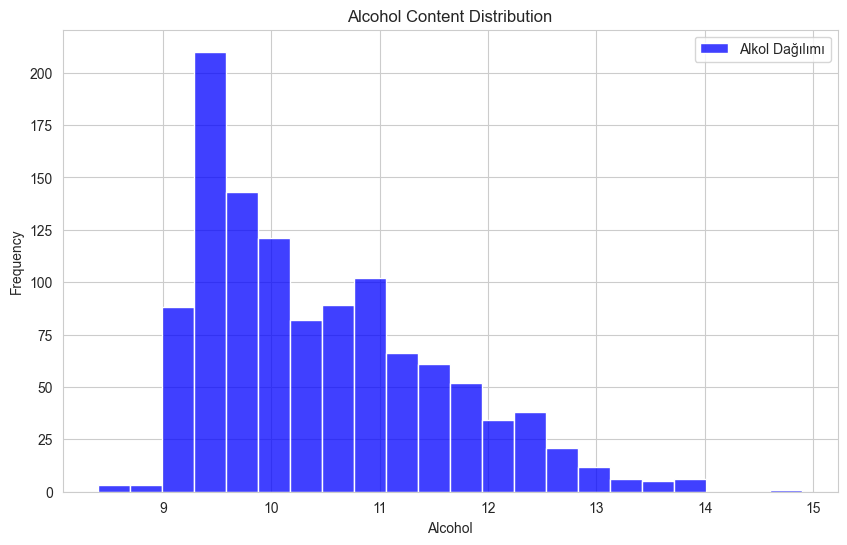

In [23]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
sns.histplot(x="alcohol", data = data, color="blue", label = "Alkol Dağılımı")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.title("Alcohol Content Distribution")
plt.legend()

plt.show()

# LOG NORMAL DAĞILIM!!!
# Bu grafikte alkol oranlarının hangi değerde daha fazla olduğunu ve hani alkol oran değerinin fazla hangisinin az olduğunu görmek istedim.

<Axes: xlabel='pH', ylabel='Count'>

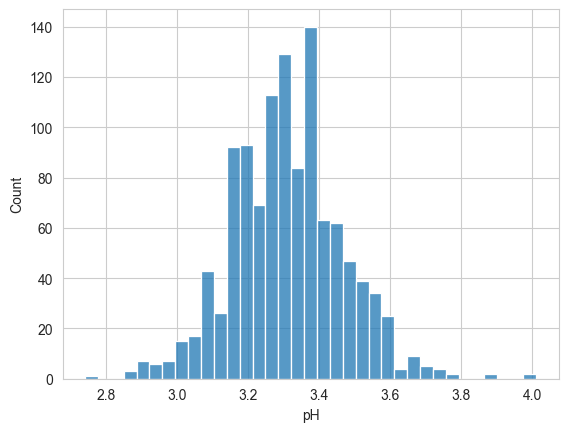

In [44]:
sns.histplot(data["pH"]) # yukarıda alcohol için yaptığım grafiğin tüm değerlerini özelleştirerek yaptık ama bu kadar kısa bir kodla daha hızlı
# sonuç alarak da istediğimiz kontrolleri yapabiliriz.

In [24]:
data["alcohol"].unique()

array([ 9.4       ,  9.8       , 10.        ,  9.5       ,  9.2       ,
        9.9       ,  9.1       , 10.5       ,  9.7       ,  9.3       ,
       10.1       ,  9.6       , 10.8       , 10.3       , 13.1       ,
       10.2       , 10.9       , 10.7       ,  9.        , 13.        ,
       14.        , 10.4       , 11.5       , 11.4       , 12.4       ,
       11.        , 12.2       , 12.8       , 12.6       , 10.6       ,
       11.7       , 12.5       , 12.        , 11.9       ,  8.7       ,
       13.3       , 12.9       , 12.3       , 11.2       , 11.1       ,
       13.4       , 11.3       , 11.6       , 12.1       , 11.8       ,
        8.4       , 12.7       , 14.9       , 13.2       , 13.6       ,
       10.03333333,  9.55      ,  8.5       , 11.06666667,  8.8       ,
       13.56666667, 11.95      ,  9.95      ,  9.23333333,  9.25      ,
       10.55      ])

In [25]:
# Outlier kontrolü yapmak için boxplot kullanacağım...

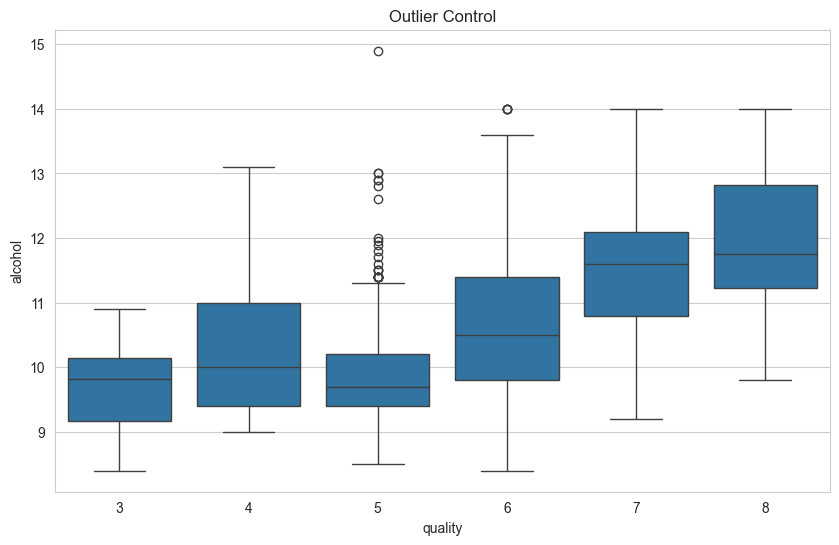

In [47]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(x="quality", y="alcohol", data=data ,) # bu değerin outlier kontrolünü yaptım.
plt.title("Outlier Control")

plt.show()

<Axes: >

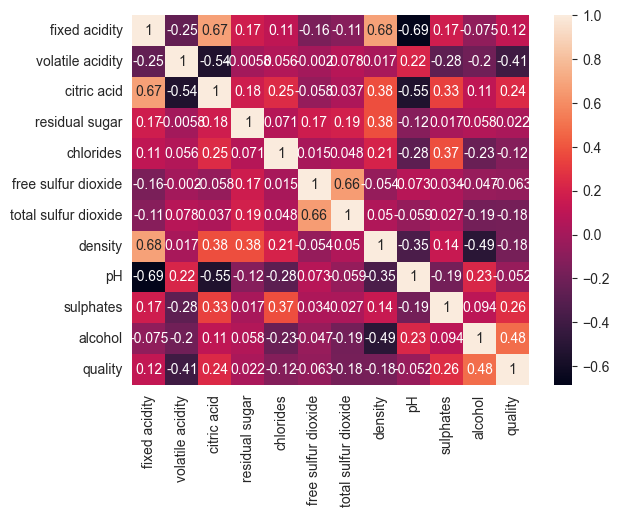

In [27]:
sns.heatmap(data.corr(), annot=True)

In [28]:
# Buradan alcohol oranının kaliteyi pozitif yönde etkileyen en önemli faktör olduğu sonucuna ulaşabiliriz.
# Volatile acidity değişkeni iste Kaliteyi kötü yönde etkileyen en önemli faktör.
# Yani bu kolerasyon şemasından Kaliteyi en çok etkileyen iki faktörün bunlar olduğunu söyleyebiliriz.

In [34]:
data.groupby("quality").mean()

# Yukarıdaki kolerasyon şemasıyla buradaki tabloyu birlikte karşılaştırabiliriz. Qualitye göre grupladık ve değerlerin değişiminin nasıl etkilediğini gördük!

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450000,0.897500,0.211667,2.666667,0.105333,8.166667,24.500000,0.997682,3.361667,0.550000,9.691667
4,7.809091,0.700000,0.165758,2.566667,0.094788,14.848485,40.606061,0.996669,3.391212,0.637879,10.260606
5,8.161077,0.585280,0.240124,2.540476,0.091770,16.612836,55.299172,0.997073,3.302091,0.613375,9.902277
6,8.317749,0.504957,0.263680,2.444805,0.085281,15.215368,39.941558,0.996610,3.323788,0.676537,10.655339
7,8.851049,0.393671,0.386573,2.760140,0.075217,14.538462,37.489510,0.996071,3.287133,0.743566,11.482634
8,8.806250,0.410000,0.432500,2.643750,0.070187,11.062500,29.375000,0.995553,3.240625,0.766250,11.937500


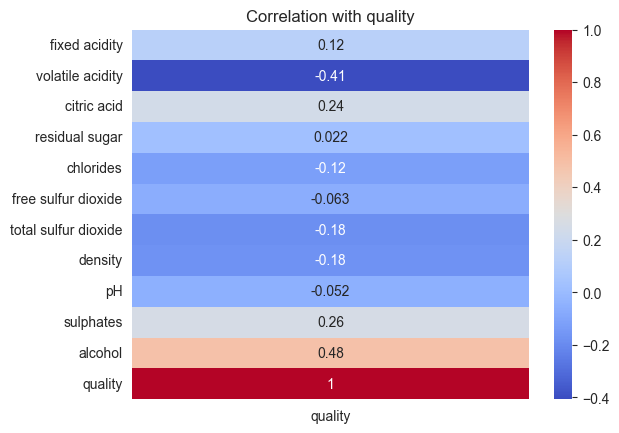

In [49]:
#Yalnızca kaliteyle diğer özelliklerin korrelasyonu için söyle bir şey de yapabiliyoruz:

# Choose the column to correlate with
target_column = 'quality'
 
# Calculate correlations with the target column
correlation_with_target = data.corr()[[target_column]]
 
# Visualize the correlation using heatmap
sns.heatmap(correlation_with_target, annot=True, cmap='coolwarm', cbar=True)
plt.title(f'Correlation with {target_column}')
plt.show()

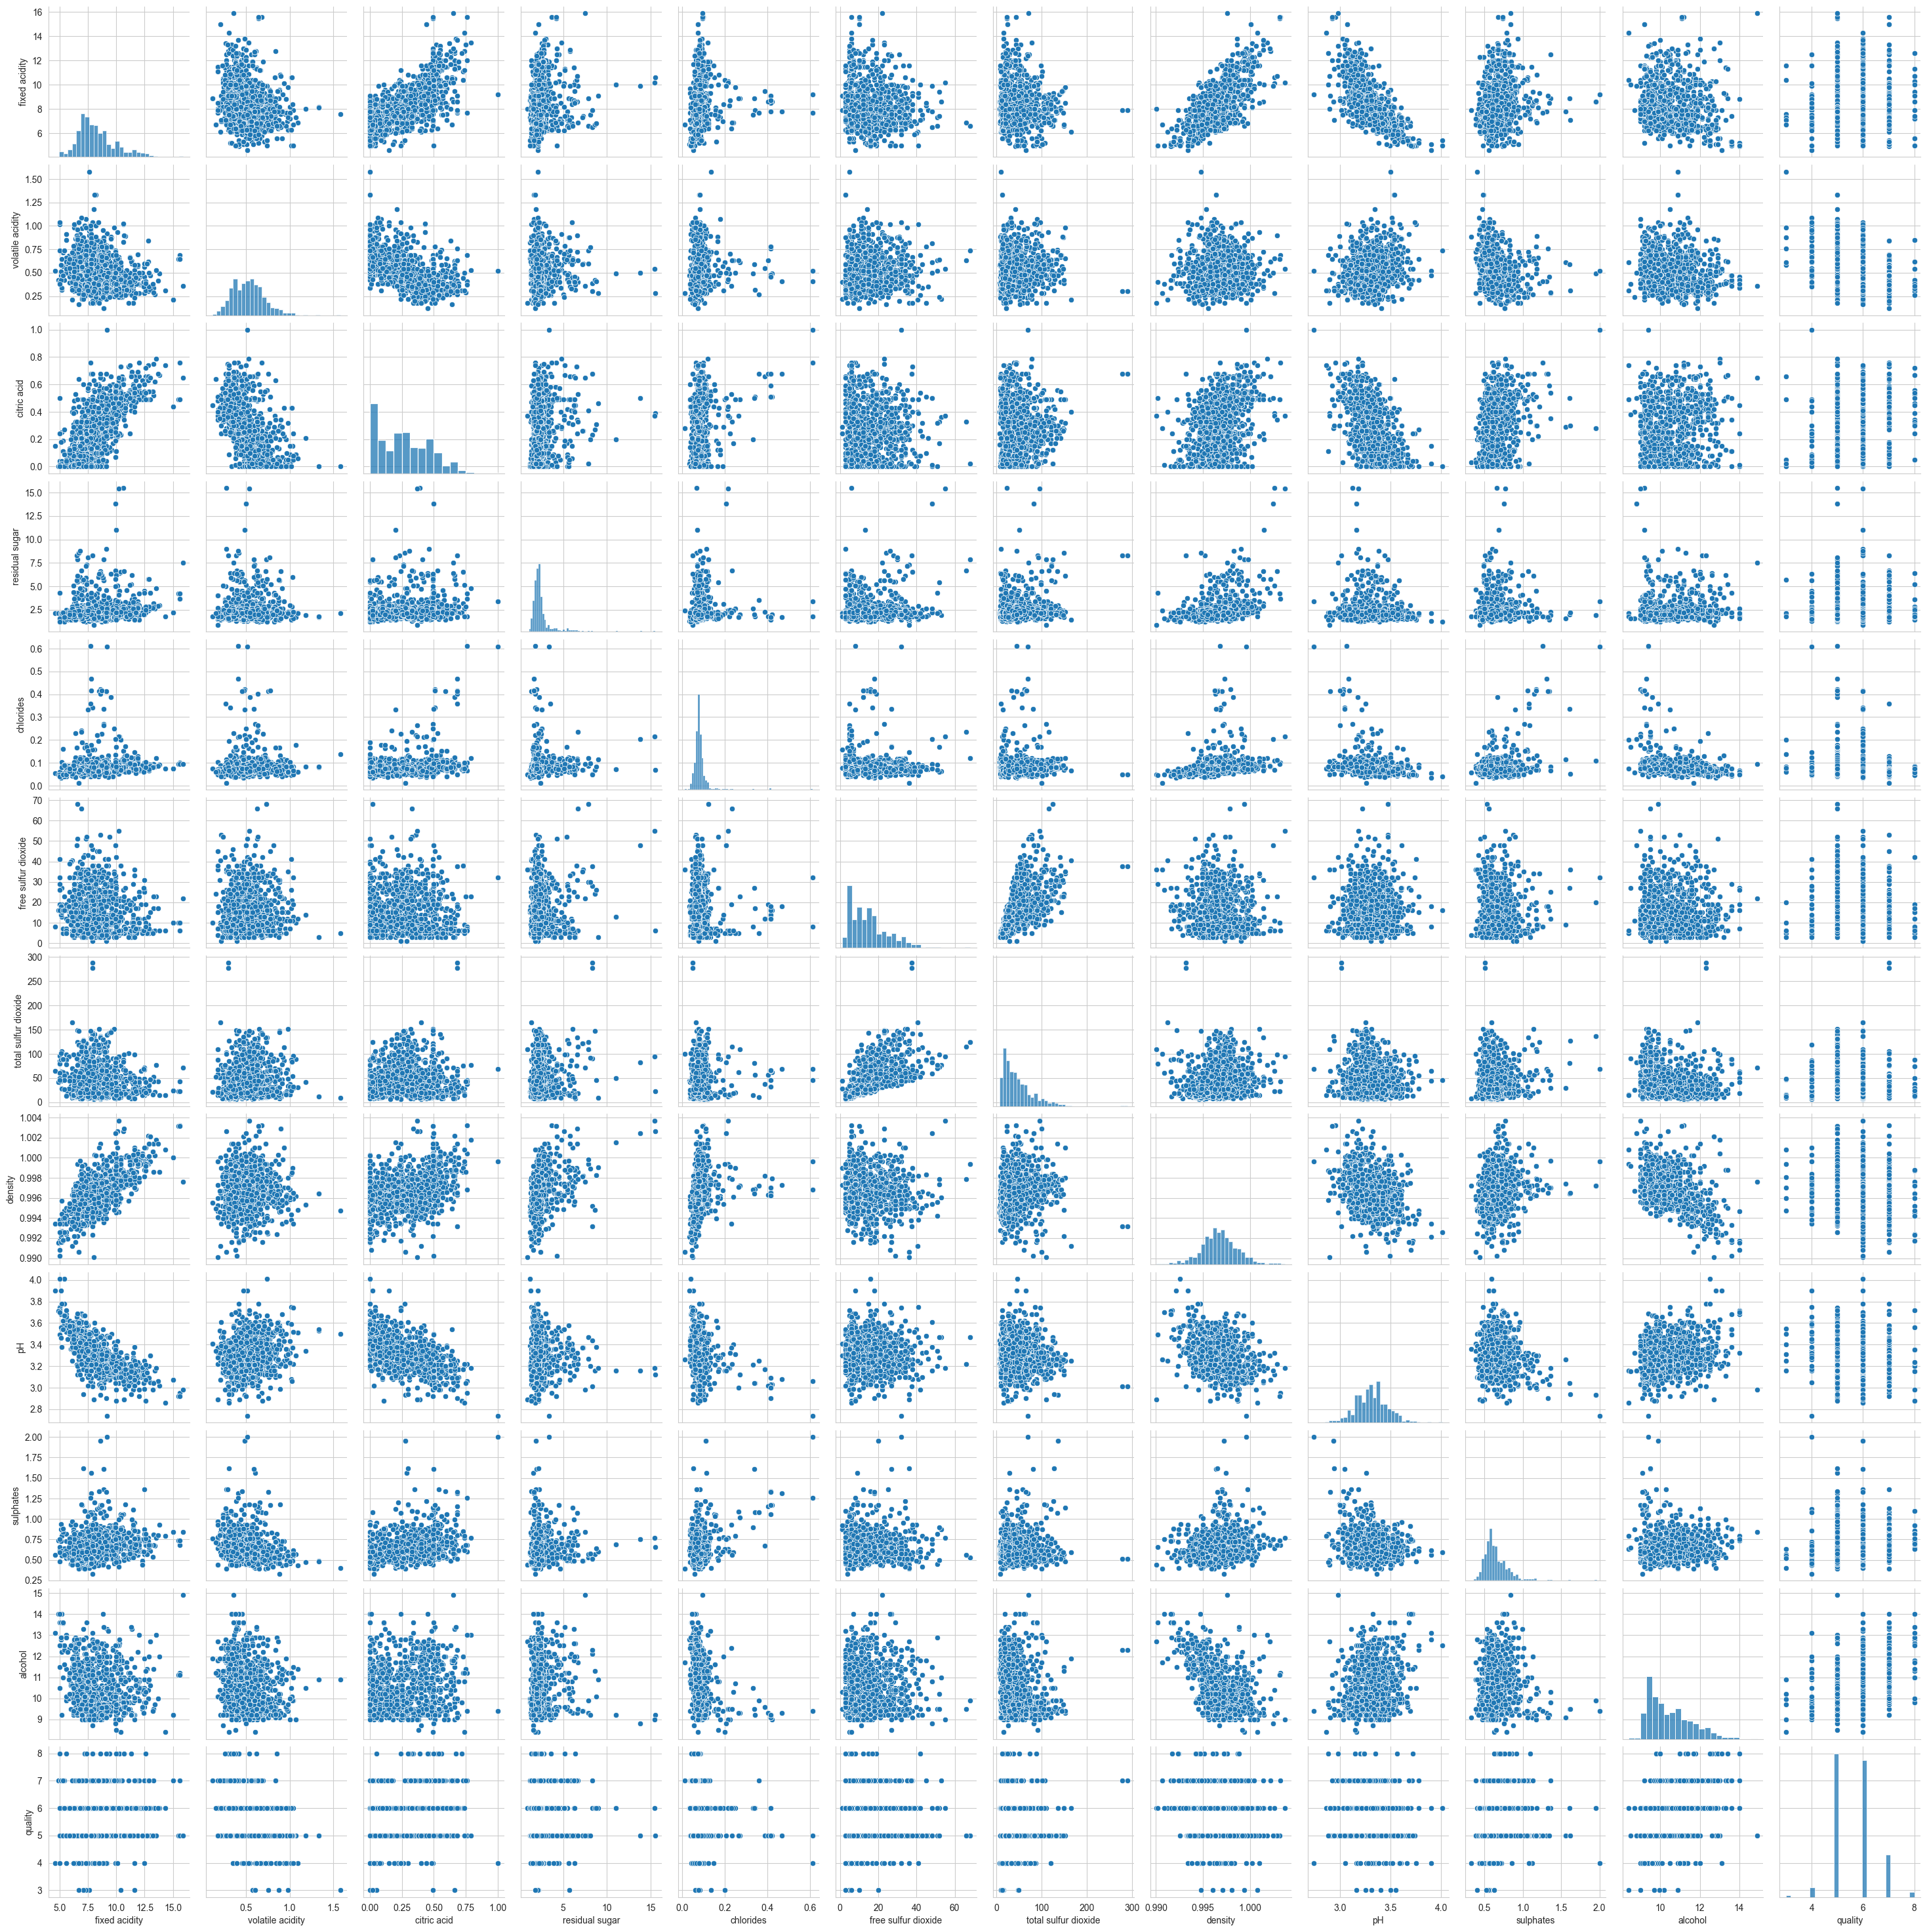

In [46]:
sns.pairplot(data)
# bütün değerleri birbiriyle kıyaslayıp en uygun grafikle görselleştiren kod!

<Axes: xlabel='fixed acidity', ylabel='density'>

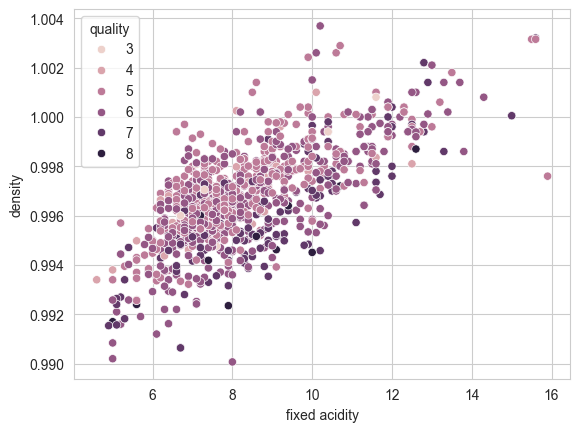

In [50]:
sns.scatterplot(x="fixed acidity", y = "density", hue="quality", data=data)

C:\Users\asus\AppData\Local\Temp\ipykernel_23556\3409292629.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


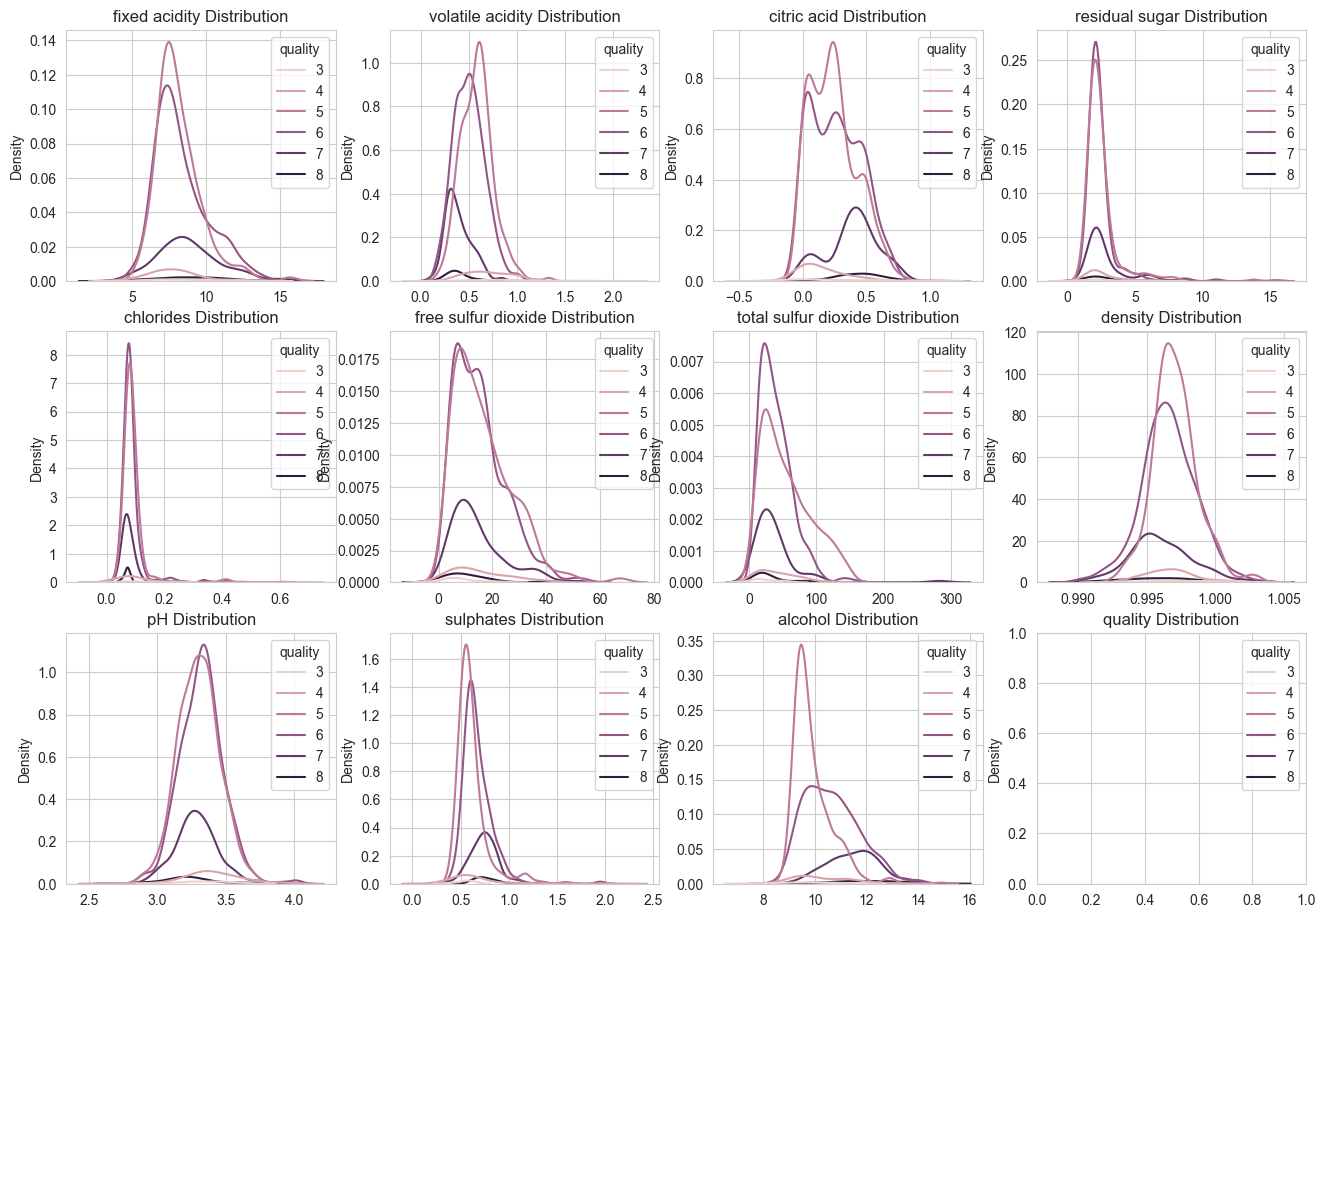

In [55]:
columns = data.columns
(fig, ax) = plt.subplots(4,4,figsize =(16,15))
ax = ax.flatten()

for i , column in enumerate(columns):
    sns.kdeplot(
        data = data,
        x = column,
        hue = data.quality,
        ax = ax[i]
    )

    ax[i].set_title(f"{column} Distribution")
    ax[i].set_xlabel(None)

for i in range(i+1, len(ax)):
    ax[i].axis("off")

In [57]:
# https://claude.ai/public/artifacts/5e64f67d-e0fa-4248-8f7f-4349ae750b30 ----> AÇIKLAMA İÇİN